In [180]:
import os
import numpy as np
import torch
import joblib
from sklearn.datasets import make_classification
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from torch import nn
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
import pickle
import matplotlib.pyplot as plt

import fsspec
import xarray as xr
import zarr

import numpy as np
from collections import defaultdict

from torchsummary import summary
from pathlib import Path



In [215]:
local_path = f"/rds/project/rds-mOlK9qn0PlQ/fairmast/upload-tmp/level2/"
fs = fsspec.filesystem('file')

# List all files and folders in the base path
all_files = fs.ls(local_path)

# Extract shot_id from the filenames
shot_ids = [file.split('/')[-1].replace('.zarr', '') for file in all_files]

# Convert them to integers
shot_ids = [int(shot_id) for shot_id in shot_ids if shot_id.isdigit()]
shot_ids = shot_ids[:20]
print(len(shot_ids))

20


In [216]:
def get_shot_fsstore(shot_id):
  local_path = f"/rds/project/rds-mOlK9qn0PlQ/fairmast/upload-tmp/level2/{shot_id}.zarr"
  fs = fsspec.filesystem('file')
  store = zarr.storage.FSStore(fs=fs, url=local_path, check=False)
  return store

# Parameters

In [249]:
# -------------------------------------------------------------------------------- #
# INPUTS 

key_list_input = { 
    'magnetics-flux_loop_flux': 't',
    'magnetics-b_field_pol_probe_ccbv_field': 't',
    'magnetics-b_field_pol_probe_obr_field': 't',
    'magnetics-b_field_pol_probe_obv_field': 't',
    'pf_active-solenoid_current': 't',
    'pf_active-coil_voltage': 't',
    'pf_active-coil_current': 't',
    'pulse_schedule-i_plasma': 't',
    'summary-power_nbi': 't',
    }

# -------------------------------------------------------------------------------- #
# OUTPUTS (only 1D)

key_list_output = {
    'equilibrium-elongation': 't+dt',
    'equilibrium-elongation_axis': 't+dt',
    'equilibrium-triangularity_upper': 't+dt',  
    'equilibrium-triangularity_lower': 't+dt',  
    'equilibrium-minor_radius': 't+dt',  
    'equilibrium-magnetic_axis_r': 't+dt',  
    'equilibrium-magnetic_axis_z': 't+dt',  
    }


## Fix a reference frequency for all variables

In [250]:
# -------------------------------------------------------------------------------- #
# TIME REFERENCE FOR PREPROCESSING 
# Chose which commmon timescale will be used for preprocessing

key_ref_time = ['equilibrium', 'elongation']

store = get_shot_fsstore('14960')
ds = xr.open_zarr(store, group=key_ref_time[0])
ref_time = ds[key_ref_time[1]].to_dataframe().reset_index().to_numpy()[:,0] # get only time

ref_freq = ref_time[2] - ref_time[1]
ref_freq = np.round(ref_freq, 3)
ref_freq

np.float64(0.005)

# Load data

In [251]:
import torch
import tensordict

def get_compatible_shots(shot_ids, key_list, output_path):


    data_dict = tensordict.TensorDict({})

    # ------------------------------------------------------------------- #
    # Fill data_dict with shots which have all the data we want!

    for shot_id in shot_ids: #i.e. all urls of level2
        print(shot_id)
        try:
            store = get_shot_fsstore(shot_id)
            data = tensordict.TensorDict({})
            for group, var in list(key.split('-') for key in key_list):
                ds = xr.open_zarr(store, group=group)
                timescale_var = torch.tensor( np.array( ds[var].time) )
                if var in ["lcfs_r", "lcfs_z"]:
                    array_var = torch.tensor( np.array( ds[var].values) )
                else: 
                    array_var = torch.tensor( np.array( ds[var].T.values) )
                data[str(group)+'-'+str(var)] = tensordict.TensorDict({'time': (timescale_var), 
                                                                        'values': (array_var)})

            # Save dictionary to a file
            # os.makedirs(output_path, exist_ok=True)
            # with open(output_path + f"shot_{shot_id}.pkl", "wb") as f:
            #     pickle.dump(data, f)

            # Store data in dictionary
            data_dict[str(shot_id)] = data

            # Save dictionary to a file
            os.makedirs(Path(output_path).parent, exist_ok=True)
            with open(output_path, "wb") as f:
                pickle.dump(data_dict, f)

            print(f"Success for shot {shot_id}")

        except Exception as e:
            print(f"Could not access all data for shot {shot_id}: {e}")

    return(data_dict)

In [252]:
output_path = "data_cecile/train/data_dict_X.pkl"
data_dict_X  = get_compatible_shots(shot_ids, key_list_input, output_path)
type(data_dict_X)

14960
Success for shot 14960
15653
Success for shot 15653
24526
Success for shot 24526
18064
Success for shot 18064
17292
Success for shot 17292
23172
Could not access all data for shot 23172: "No variable named 'power_nbi'. Did you mean one of ('power_radiated',)?"
23905
Success for shot 23905
29501
Success for shot 29501
20172
Success for shot 20172
16238
Success for shot 16238
20114
Success for shot 20114
12951
Success for shot 12951
29679
Success for shot 29679
18324
Success for shot 18324
18749
Success for shot 18749
14194
Success for shot 14194
16275
Success for shot 16275
20427
Could not access all data for shot 20427: "No variable named 'coil_voltage'. Variables on the dataset include ['channel', 'coil_current', 'solenoid_current', 'time']"
13721
Success for shot 13721
16392
Success for shot 16392


tensordict._td.TensorDict

In [253]:
output_path = "data_cecile/train/data_dict_y.pkl"
data_dict_y  = get_compatible_shots(shot_ids, key_list_output, output_path)
type(data_dict_y)

14960
Success for shot 14960
15653
Success for shot 15653
24526
Success for shot 24526
18064
Success for shot 18064
17292
Success for shot 17292
23172
Success for shot 23172
23905
Success for shot 23905
29501
Success for shot 29501
20172
Success for shot 20172
16238
Success for shot 16238
20114
Success for shot 20114
12951
Success for shot 12951
29679
Success for shot 29679
18324
Success for shot 18324
18749
Success for shot 18749
14194
Success for shot 14194
16275
Success for shot 16275
20427
Success for shot 20427
13721
Success for shot 13721
16392
Success for shot 16392


tensordict._td.TensorDict

In [254]:
with open('data_cecile/train/data_dict_X.pkl', 'rb') as f:
    data_dict_X = pickle.load(f)

with open('data_cecile/train/data_dict_y.pkl', 'rb') as f:
    data_dict_y = pickle.load(f)
    data_dict_y = tensordict.TensorDict({k: data_dict_y[k] for k in data_dict_X.keys()})
print(type(data_dict_y))

print( 'Both X and y have the same shots :', data_dict_X.keys() == data_dict_y.keys()  )

<class 'tensordict._td.TensorDict'>
Both X and y have the same shots : True


## Snapchot of what the loaded data look like!

In [255]:
data_dict_X.keys()

_StringKeys(dict_keys(['14960', '15653', '24526', '18064', '17292', '23905', '29501', '20172', '16238', '20114', '12951', '29679', '18324', '18749', '14194', '16275', '13721', '16392']))

In [256]:
data_dict_X['14960'].keys()

_StringKeys(dict_keys(['magnetics-flux_loop_flux', 'magnetics-b_field_pol_probe_ccbv_field', 'magnetics-b_field_pol_probe_obr_field', 'magnetics-b_field_pol_probe_obv_field', 'pf_active-solenoid_current', 'pf_active-coil_voltage', 'pf_active-coil_current', 'pulse_schedule-i_plasma', 'summary-power_nbi']))

In [257]:
data_dict_X['14960']['magnetics-flux_loop_flux'].keys()

_StringKeys(dict_keys(['time', 'values']))

In [258]:
# get multiple keys from same level
for shot in ('14960', '15653'):
    print( data_dict_X.get(( (shot,'magnetics-flux_loop_flux','values') )) )

data_dict_X.select('14960', '15653').keys()

tensor([[ 0.1204,  0.1215,  0.1218,  ...,  0.0602,  0.0500,     nan],
        [ 0.1211,  0.1225,  0.1229,  ...,  0.0612,  0.0500,     nan],
        [ 0.1218,  0.1232,  0.1236,  ...,  0.0622,  0.0500,     nan],
        ...,
        [-0.0722, -0.0731, -0.0734,  ..., -0.2380, -0.2725,     nan],
        [-0.0712, -0.0723, -0.0726,  ..., -0.2371, -0.2705,     nan],
        [-0.0712, -0.0723, -0.0726,  ..., -0.2371, -0.2705,     nan]],
       dtype=torch.float64)
tensor([[ 0.1112,  0.1126,  0.1127,  ...,  0.0554,  0.0438,     nan],
        [ 0.1122,  0.1133,  0.1135,  ...,  0.0554,  0.0448,     nan],
        [ 0.1129,  0.1143,  0.1142,  ...,  0.0564,  0.0457,     nan],
        ...,
        [-0.0373, -0.0377, -0.0379,  ..., -0.2477, -0.2944,     nan],
        [-0.0366, -0.0372, -0.0372,  ..., -0.2458, -0.2925,     nan],
        [-0.0363, -0.0365, -0.0369,  ..., -0.2438, -0.2915,     nan]],
       dtype=torch.float64)


_StringKeys(dict_keys(['14960', '15653']))

In [259]:
# apply nested keys 
data_dict_X['15653']['magnetics-flux_loop_flux']['values']
# or
data_dict_X.get(('15653','magnetics-flux_loop_flux','values'))

tensor([[ 0.1112,  0.1126,  0.1127,  ...,  0.0554,  0.0438,     nan],
        [ 0.1122,  0.1133,  0.1135,  ...,  0.0554,  0.0448,     nan],
        [ 0.1129,  0.1143,  0.1142,  ...,  0.0564,  0.0457,     nan],
        ...,
        [-0.0373, -0.0377, -0.0379,  ..., -0.2477, -0.2944,     nan],
        [-0.0366, -0.0372, -0.0372,  ..., -0.2458, -0.2925,     nan],
        [-0.0363, -0.0365, -0.0369,  ..., -0.2438, -0.2915,     nan]],
       dtype=torch.float64)

## Forward Filling Block

In [260]:
import torch
import pandas as pd
class ForwardFillImputerTransform:
    def __call__(self, dict):
        """
        Input: torch dict with key 'time' and key 'values'
        Returns: torch dict with key 'time' and key 'values with NaNs forward-filled
        """
        time = dict['time']
        values = dict['values']
        if not isinstance(values, torch.Tensor):
            raise TypeError(f"Expected torch.Tensor, got {type(values)}")
        # Convert to NumPy for forward-filling
        values_np = values.detach().cpu().numpy()
        df = pd.DataFrame(values_np)
        # print('\nBefore forward filling: ', list(df.isna().sum(axis=0)))
        df = df.ffill(axis=0)
        # print('After forward filling: ', list(df.isna().sum(axis=0)))
        
        return tensordict.TensorDict( {'time': time,
                                       'values': torch.tensor(df.values, dtype=values.dtype, device=values.device) } )


## Fill Nan with Zeros Block

In [261]:
import torch
import pandas as pd
class FillWithZerosImputerTransform:
    def __call__(self, dict):
        """
        Input: torch dict with key 'time' and key 'values'
        Returns: torch dict with key 'time' and key 'values with NaNs filled with zeros
        """
        time = dict['time']
        values = dict['values']
        if not isinstance(values, torch.Tensor):
            raise TypeError(f"Expected torch.Tensor, got {type(values)}")
        # Convert to NumPy for forward-filling
        values_np = values.detach().cpu().numpy()
        df = pd.DataFrame(values_np)
        print('\nBefore filling with zeros: ', list(df.isna().sum(axis=0)))
        df = df.fillna(value=0)
        print('After filling with zeros: ', list(df.isna().sum(axis=0)))
        
        return tensordict.TensorDict( {'time': time,
                                       'values': torch.tensor(df.values, dtype=values.dtype, device=values.device) } )


## Move data to reference frequency

In [262]:
class SamplingtoReferenceTimeTransform:
    def __init__(self, ref_freq):
        self.ref_freq = ref_freq
    def __call__(self, dict):
        """
        Input:
        torch dict with key 'time' and key 'values'
        Returns: torch dict with key 'time' and key 'values with NaNs forward-filled
        """
        time = dict['time']
        values = dict['values']
        if not isinstance(values, torch.Tensor):
            raise TypeError(f"Expected torch,Tensor, got {type(values)}")
        # Create reference scale
        ref_time = []
        for k in range (0, int( (time[-1]-time[0])/(self.ref_freq))+2):
            ref_time. append ( time[0] + k*self.ref_freq )

        # Upsample or subsample by picking the closest value in time to the ref_time
        idx = np.searchsorted(time, ref_time) # reformat to be on the same scale as ref_time
        idx = np. clip(idx, 1, len(time) - 1)
        values_rescaled = values[idx]
        # print('\nAfter time rescaling', len(values_rescaled) )
        return tensordict.TensorDict( {'time': ref_time,
                                      'values': values_rescaled } )

## CustomPreprocessor: TensorDict --> TensorDict

In [263]:
from sklearn.base import BaseEstimator, TransformerMixin
import tensordict

class CustomPreprocessor(BaseEstimator, TransformerMixin):
    def __init__(self, key_transform_map_X, key_transform_map_y=None):
        """
        key_transform_map_X: dict of transforms for input X
        key_transform_map_y: dict of transforms for target y
        """
        self.key_transform_map_X = key_transform_map_X
        self.key_transform_map_y = key_transform_map_y or {}

    def fit(self, X, y=None):
        return self  # Stateless transformer

    def transform(self, X, y=None):
        X_transformed = self._apply_transform_recursively(X, self.key_transform_map_X)
        y_transformed = (
            self._apply_transform_recursively(y, self.key_transform_map_y) if y is not None else None
        )
        return (X_transformed, y_transformed) if y is not None else X_transformed

    def fit_transform(self, X, y=None):
        self.fit(X, y)
        return self.transform(X, y)

    def _apply_transform_recursively(self, d, key_transform_map, current_path=""):
        if isinstance(d, tensordict.TensorDict):
            new_dict = {}
            for k, v in d.items():
                key_path = f"{current_path}/{k}" if current_path else k
                if k in key_transform_map:
                    print(k)
                    # Apply transform if key matches ie if last dict
                    new_dict[k] = key_transform_map[k](v)
                elif isinstance(v, tensordict.TensorDict):
                    # Recurse into nested TensorDict
                    new_dict[k] = self._apply_transform_recursively(v, key_transform_map, key_path)
                else:
                    new_dict[k] = v  # Leave unchanged
            return tensordict.TensorDict(new_dict, batch_size=d.batch_size)
        print('data passed is not a tensordict!')
        return d


In [264]:
# Here basically we apply the same transform for everybody group-variable
# To change depending on transfroms we want to apply to which group-variable

# Transforms for X
key_transform_map_X = {k: transforms.Compose(
                [
                ForwardFillImputerTransform(), # Forward-Filling
                FillWithZerosImputerTransform(), # Fill rest of the nans with zeros
                SamplingtoReferenceTimeTransform(ref_freq) # Put all variables to same frequencies
                ]
                ) for k in list(key_list_input.keys())}

# Transforms for y
key_transform_map_y = {k: transforms.Compose(
                [
                ForwardFillImputerTransform(),
                FillWithZerosImputerTransform(),
                SamplingtoReferenceTimeTransform(ref_freq)
                ]
                ) for k in list(key_list_output.keys())}


preprocessor = CustomPreprocessor(key_transform_map_X=key_transform_map_X, 
                                  key_transform_map_y=key_transform_map_y)

X_transformed, y_transformed = preprocessor.transform(data_dict_X, data_dict_y)

print('\nOG data of shape:', data_dict_X['14960']['magnetics-flux_loop_flux']['values'].shape)
print(data_dict_X['14960']['magnetics-flux_loop_flux']['values'])

print('\nTransformed data of shape:', X_transformed['14960']['magnetics-flux_loop_flux']['values'].shape)
print(X_transformed['14960']['magnetics-flux_loop_flux']['values'])

print('\nTransformed y data of shape:', data_dict_y['14960']['equilibrium-elongation']['values'].shape)
print(data_dict_y['14960']['equilibrium-elongation']['values'])

print('\nTransformed y data of shape:', y_transformed['14960']['equilibrium-elongation']['values'].shape)
print(y_transformed['14960']['equilibrium-elongation']['values'])

magnetics-flux_loop_flux

Before filling with zeros:  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3287]
After filling with zeros:  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
magnetics-b_field_pol_probe_ccbv_field

Before filling with zeros:  [0, 0, 0, 0, 0, 0, 0, 0, 0, 3287, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3287, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
After filling with zeros:  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
magnetics-b_field_pol_probe_obr_field

Before filling with zeros:  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
After filling with zeros:  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
magnetics-b_field_pol_probe_obv_field

Before filling with zeros:  [0, 0, 0, 0, 0, 0, 0, 0, 0, 3287, 0, 0, 0, 0, 0, 0, 0, 0]
After filling with zeros:  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
pf_active-solenoid_current

Before filling with zeros:  [0]
After fill

/home/ir-rous1/conda/envs/myenvpy310fusion/lib/python3.10/site-packages/tensordict/base.py:11346: FutureWarning: You are setting a list of elements within a tensordict without setting `set_list_to_stack`. The current behaviour is that: if this list can be cast to a Tensor, it will be and will be written as such. If it cannot, it will be converted to a numpy array and considered as a non-indexable entity through a wrapping in a NonTensorData. If you want your list to be indexable along the tensordict batch-size, use the decorator/context manager tensordict.set_list_to_stack(True), the global flag `tensordict.set_list_to_stack(True).set()`, or the environment variable LIST_TO_STACK=1 (or use False/0 to silence this warning). This behavior will change in v0.10.0, and lists will be automatically stacked.
  warnings.warn(


pulse_schedule-i_plasma

Before filling with zeros:  [0]
After filling with zeros:  [0]
summary-power_nbi

Before filling with zeros:  [5]
After filling with zeros:  [0]
magnetics-flux_loop_flux

Before filling with zeros:  [0, 0, 0, 0, 0, 3198, 0, 0, 0, 0, 0, 0, 0, 0, 0]
After filling with zeros:  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
magnetics-b_field_pol_probe_ccbv_field

Before filling with zeros:  [0, 3198, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3198, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3198, 0, 0, 3198, 0, 0, 0, 0, 0]
After filling with zeros:  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
magnetics-b_field_pol_probe_obr_field

Before filling with zeros:  [0, 3198, 3198, 0, 0, 0, 3198, 0, 0, 0, 3198, 0, 0, 0, 0, 0, 0, 0]
After filling with zeros:  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
magnetics-b_field_pol_probe_obv_field

Before filling with zeros:  [3198, 3198, 0, 0, 0, 

## CNN-specific block: TensorDict --> List of Arrays
### 1. Concatenate along time given time alignement of interest t and t+dt
### 2. Group by shapes to reduce number of embedding branches of the CNN

In [265]:
# Get which decalage dt I want for training data
dt = int(np. round (0.025 / ref_freq) )
print(dt)

5


In [266]:
import torch
import numpy as np
from collections import defaultdict
from sklearn.base import BaseEstimator, TransformerMixin

class CNNmodelConcatenator(BaseEstimator, TransformerMixin):
    def __init__(self, key_list_X, key_list_y = None, dt=1, to_numpy=True):
        self.key_list_X = key_list_X
        self.key_list_y = key_list_y
        self.dt = dt
        self.to_numpy = to_numpy

    def fit(self, X, y=None):
        return self

    def transform(self, data_dict_X, data_dict_y=None):
        
        X=[]
        y=[]

        X_processed = self._process_vars(data_dict_X, self.key_list_X)

        if data_dict_y is not None:
            
            y_processed = self._process_vars(data_dict_y, self.key_list_y)

            for shot_idx in range(len(X_processed)):
                X_shot = X_processed[shot_idx]
                y_shot = y_processed[shot_idx]
                min_common_time = min(min(arr.shape[0] for arr in X_shot),
                                    min(arr.shape[0] for arr in y_shot))
                print('min_common_time', min_common_time)
                X.append([arr[:min_common_time] for arr in X_shot])
                y.append([arr[:min_common_time] for arr in y_shot])

            print('X', [len(arr[0]) for arr in [X[k] for k in range(0, len(X))] ])
            print('y', [len(arr[0]) for arr in [y[k] for k in range(0, len(y))] ])

            X_concat = self._concatenate_along_time(X)
            y_concat = self._concatenate_along_time(y)

            reshaped_X = self._group_arrays_by_shape(X_concat)
            reshaped_y = self._group_arrays_by_shape(y_concat)

            print([arr.shape for arr in reshaped_X])
            print([arr.shape for arr in reshaped_y])

            if isinstance(reshaped_y, list) and len(reshaped_y) == 1:
                reshaped_y = reshaped_y[0]

            reshaped_X = [x.squeeze(-1) if x.shape[-1] == 1 else x for x in reshaped_X]
            reshaped_y = reshaped_y.squeeze(-1) if reshaped_y.shape[-1] == 1 else reshaped_y

            print([arr.shape for arr in reshaped_X])
            print([arr.shape for arr in reshaped_y])

            print('nan in X', [np.any(np.isnan(arr)) for arr in reshaped_X])
            print('nan in y', np.any(np.isnan(reshaped_y)))

            return reshaped_X, reshaped_y
        
        if data_dict_y is None:

            # Per shot, find minimum common length across all variables in X 
            for shot_idx in range(len(X_processed)):
                X_shot = X_processed[shot_idx]
                min_X_time = min(arr.shape[0] for arr in X_shot)
                print('min_common_time', min_X_time)
                X.append([arr[:min_X_time] for arr in X_shot])

            print('X', [len(arr[0]) for arr in [X[k] for k in range(0, len(X))] ])

            X_concat = self._concatenate_along_time(X)

            reshaped_X = self._group_arrays_by_shape(X_concat)
            
            print([arr.shape for arr in reshaped_X])

            reshaped_X = [x.squeeze(-1) if x.shape[-1] == 1 else x for x in reshaped_X]
            
            return reshaped_X
    
    def fit_transform(self, X, y=None):
        self.fit(X, y)
        return self.transform(X, y)

    def _process_vars(self, data_dict, key_list):
        processed = []
        for shot_id in data_dict.keys():
            shot_vars = []
            for var, data in data_dict[shot_id].items():
                if var in key_list:
                    values = data['values']
                    t_mode = key_list[var]
                    if t_mode == 't':
                        shot_vars.append(values[:-self.dt])
                    elif t_mode == 't+dt':
                        shot_vars.append(values[self.dt:])
            processed.append(shot_vars)
        return processed

    def _concatenate_along_time(self, list_of_tensors):
        # Transpose the list of lists to group tensors by their position
        arr_grouped = list(zip(*list_of_tensors))
        # Concatenate each group along dim=0
        return [torch.cat(tensors, dim=0) for tensors in arr_grouped]

    def _group_arrays_by_shape(self, arrays):
        grouped = defaultdict(list)
        for arr in arrays:
            grouped[arr.shape].append(arr)

        reshaped_list = []
        for same_shape_group in grouped.values():
            stacked = np.stack(
                [a.numpy() if self.to_numpy and hasattr(a, 'numpy') else a for a in same_shape_group]
            )
            transposed = np.transpose(stacked, axes=[1, 0] + list(range(2, stacked.ndim)))
            reshaped_list.append(transposed)
        return reshaped_list


## Combination of transform + data formatting for CNN

In [267]:
# class CustomPipeline:
#     def __init__(self, steps):
#         self.steps = steps

#     def fit(self, X, y=None):
#         # for name, step in self.steps[:-1]:  # All except last (model)
#         for name, step in self.steps[:]:  # All except last (model)
#             X, y = step.fit_transform(X, y)
#         # self.steps[-1][1].fit(X, y)  # Fit the model
#         # return X, y
#         return self

#     def predict(self, X, y=None):
#         # for name, step in self.steps[:-1]:
#         for name, step in self.steps[:]:
#             print(name)
#             X = step.transform(X)
#         # return self.steps[-1][1].predict(X)
#         return X

In [268]:
class CustomPipeline:
    def __init__(self, steps):
        self.steps = steps

    def fit(self, X, y=None):
        for name, step in self.steps[:-1]:  # Preprocessing steps
            X, y = step.fit_transform(X, y)

        model_name, model = self.steps[-1]
        model.fit(X, y)  # Train the model
        return self

    def predict(self, X, y=None):
        for name, step in self.steps[:-1]:  # Only transform before the model
            if y is not None:
                X, y = step.transform(X, y)
            else:
                X = step.transform(X)
        return self.steps[-1][1].predict(X)

    def fit_transform(self, X, y=None):
        for name, step in self.steps[:-1]:
            X, y = step.fit_transform(X, y)
        return X, y

    def transform(self, X, y=None):
        for name, step in self.steps[:-1]:
            if y is not None:
                X, y = step.transform(X, y)
            else:
                X = step.transform(X)
        return (X, y) if y is not None else X

In [269]:
data_dict_y['14960'].keys()

_StringKeys(dict_keys(['equilibrium-elongation', 'equilibrium-elongation_axis', 'equilibrium-triangularity_upper', 'equilibrium-triangularity_lower', 'equilibrium-minor_radius', 'equilibrium-magnetic_axis_r', 'equilibrium-magnetic_axis_z']))

In [270]:
# Here basically we apply the same transform for everybody group-variable
# To change depending on transfroms we want to apply to which group-variable

# Transforms for X
key_transform_map_X = {k: transforms.Compose(
                [
                ForwardFillImputerTransform(), # Forward-Filling
                FillWithZerosImputerTransform(), # Fill rest of the nans with zeros
                SamplingtoReferenceTimeTransform(ref_freq) # Put all variables to same frequencies
                ]
                ) for k in list(key_list_input.keys())}

# Transforms for y
key_transform_map_y = {k: transforms.Compose(
                [
                ForwardFillImputerTransform(),
                FillWithZerosImputerTransform(),
                SamplingtoReferenceTimeTransform(ref_freq)
                ]
                ) for k in list(key_list_output.keys())}


preprocessor = CustomPreprocessor(key_transform_map_X, key_transform_map_y)

pipeline = CustomPipeline([
    ("preprocessor", preprocessor),
    ("cnn_flattener", CNNmodelConcatenator(
        key_list_X = key_list_input,
        key_list_y = key_list_output,
        dt=dt,
        to_numpy=True)),
    ("model", 'dummy')
])

reshaped_X, reshaped_y = pipeline.transform(data_dict_X, data_dict_y)

print('\n Shape of inputs for CNN')
print([arr.shape for arr in reshaped_X])

print('\n Shape of outputs for CNN')
print(reshaped_y.shape)

magnetics-flux_loop_flux

Before filling with zeros:  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3287]
After filling with zeros:  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
magnetics-b_field_pol_probe_ccbv_field

Before filling with zeros:  [0, 0, 0, 0, 0, 0, 0, 0, 0, 3287, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3287, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
After filling with zeros:  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
magnetics-b_field_pol_probe_obr_field

Before filling with zeros:  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
After filling with zeros:  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
magnetics-b_field_pol_probe_obv_field

Before filling with zeros:  [0, 0, 0, 0, 0, 0, 0, 0, 0, 3287, 0, 0, 0, 0, 0, 0, 0, 0]
After filling with zeros:  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
pf_active-solenoid_current

Before filling with zeros:  [0]
After fill

In [271]:
# input_shapes = [x.shape[1:] for x in reshaped_X]
# print(input_shapes)
# output_dim = reshaped_y.shape[1]
# print(output_dim)

## CNN Model + CNN Model Wrapper

In [272]:
# # Example input shapes: [(1, 15), (1, 40), (2, 18), (3, 1), (2, 14)]
# input_shapes = [(1, 15), (1, 40), (2, 18), (3, 1), (2, 14)]
# output_dim = 7

# import numpy as np

# def generate_synthetic_data(input_shapes, output_dim=1, n_samples=500):
#     X = [np.random.randn(n_samples, *shape).astype(np.float32) for shape in input_shapes]
#     y = np.stack ( [np.random.randn(n_samples, output_dim).astype(np.float32)])
#     return X, y

# X, y = generate_synthetic_data(input_shapes, output_dim)

# # Initialize the wrapper
# lazy_model = CNNModelWrapper(
#     model_cls=AdaptiveMultiInputRegressionModel,
#     model_kwargs={'D': 16},
#     epochs=5,
#     batch_size=32
# )

# # Fit the model
# lazy_model.fit(X, y)

# # Predict on the same data
# y_pred = lazy_model.predict(X)

# print("Predicted shape:", y_pred.shape)  # Should be (n_samples, output_dim)


In [273]:
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

D = 16  # Base dimension

# ---------------------------------------------------------------------------------------------------------------- #
# EMBEDDING LAYERS

def small_cnn_embedding_branch(input_shape, D):
    
    inputA = layers.Input(shape=input_shape)
    # x = layers.BatchNormalization()(inputA)
    
    # Transpose: (batch, time, features) -> (batch, features, time)
    x = layers.Lambda(lambda t: tf.transpose(t, perm=[0, 2, 1]))(inputA)
    x = layers.BatchNormalization()(x)
    x = layers.Conv1D(D, kernel_size=3, strides=1, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(pool_size=2)(x)
    x = layers.Conv1D(2 * D, kernel_size=3, strides=1, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(pool_size=2)(x)
    x = layers.Conv1D(4 * D, kernel_size=3, strides=1, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    # x = layers.MaxPooling1D(pool_size=2)(x)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(input_shape[0], activation='relu')(x)
    return Model(inputs=inputA, outputs=x, name="small_CNN_Branch")


# Function to create the numerical input branch
def numerical_embedding_branch(input_shape):
    inputB = layers.Input(shape=input_shape)
    y = layers.BatchNormalization()(inputB)
    
    return Model(inputs=inputB, outputs=y, name="Numerical_Branch")



# ---------------------------------------------------------------------------------------------------------------- #
# PREDICTION LAYERS

# Function to create the fully connected layers after merging
def fully_connected_layers(merged_input, output_shape):
    x = layers.BatchNormalization()(merged_input)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(32, activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(rate=0.2)(x)
    # output = layers.Dense(1)(x)  # Single output regression
    output = layers.Dense(output_shape)(x)  # Single output regression

    return output

# ---------------------------------------------------------------------------------------------------------------- #
# MODEL


class Adaptive_MultiInputRegressionModel(Model):
    # def __init__(self, input_shape_1=(120,3), input_shape_2=(100,5), input_shape_3=(15,)):
    def __init__(self, input_shapes, output_shape):  # input_shapes is a list or tuple of shapes

        super(Adaptive_MultiInputRegressionModel, self).__init__()
        
        self.branches = []

        for input_shape in input_shapes:
            print(input_shape)
            
            # 0D data
            if len(input_shape) == 1:
                print('input_shape', input_shape)
                self.branches.append(numerical_embedding_branch(input_shape))
                print('num ok')
                # print( numerical_embedding_branch(input_shape).summary() ) 
            
            # 1D data
            if len(input_shape) == 2:
                    self.branches.append(small_cnn_embedding_branch(input_shape, D))
                    # print( small_cnn_embedding_branch(input_shape, D).summary() ) 
                
        # Merge branches
        combined = layers.concatenate([branch.output for branch in self.branches])

        # Fully connected layers
        output = fully_connected_layers(combined, output_shape)

        # Define model
        self.model = Model(inputs=[branch.input for branch in self.branches], outputs=output)
        print(self.model.summary())

        # Compile model
        self.model.compile(optimizer=Adam(learning_rate=1e-4, clipnorm=1.0), loss="mse", metrics=["mae"])
    
    def call(self, inputs):
        return self.model(inputs)
    
    def train(self, X_train, y_train, 
              X_val, y_val, 
              epochs=500, 
              batch_size=32):

        # Define early stopping
        early_stopping = EarlyStopping(
            monitor="val_loss",   # Monitor validation loss
            patience=10,          # Stop if no improvement for 10 epochs
            restore_best_weights=True  # Restore the best weights after stopping
        )

        return self.model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=epochs,
            batch_size=batch_size,
            callbacks=[early_stopping]
        )
    
    def evaluate_model(self, X_val, y_val):
        return self.model.evaluate(X_val, y_val)
    
    def predict_model(self, X_test):
        return self.model.predict(X_test)



In [274]:
from sklearn.base import BaseEstimator, RegressorMixin
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model

class KerasModelWrapper(BaseEstimator, RegressorMixin):
    def __init__(self, model_cls, model_kwargs=None, epochs=10, batch_size=32):
        """
        model_cls: class - should be a class like Adaptive_MultiInputRegressionModel
        model_kwargs: dict - kwargs to pass into model_cls
        """
        self.model_cls = model_cls
        self.model_kwargs = model_kwargs or {}
        self.epochs = epochs
        self.batch_size = batch_size
        self.model = None

    def fit(self, X, y=None):

        # print('cece C', X)

        # If X is a list of arrays, use directly. Otherwise, raise helpful error.
        if not isinstance(X, list) or not all(isinstance(x, np.ndarray) for x in X):
            raise ValueError("Expected X to be a list of numpy arrays after preprocessing.")

        X_np = X
        y_np = np.squeeze( np.array(y, dtype=np.float32) )
        # y_np = np.squeeze(y[0])

        input_shapes = [x.shape[1:] for x in X_np]
        output_shape = y_np.shape[1] if y_np.ndim > 1 else 1

        self.model = self.model_cls(input_shapes=input_shapes, output_shape=output_shape, **self.model_kwargs)
        self.model.train(X_np, y_np, X_np, y_np, epochs=self.epochs, batch_size=self.batch_size)

        return self


    def predict(self, X):
        X = [np.asarray(x, dtype=np.float32) for x in X]
        return self.model.predict_model(X)

    def score(self, X, y):
        X = [np.asarray(x, dtype=np.float32) for x in X]
        y = np.asarray(y, dtype=np.float32)
        loss, mae = self.model.evaluate_model(X, y)
        return -mae  # In scikit-learn, higher scores are better (negate MAE)


In [275]:
# # test of CNN model on synthetic data

# input_shapes = [(1, 15), (1, 40), (2, 18), (3,), (2, 14)]
# output_dim = (7,)

# import numpy as np

# def generate_synthetic_data(input_shapes, output_dim=1, n_samples=50):
#     X = [np.random.randn(n_samples, *shape).astype(np.float32) for shape in input_shapes]
#     # y = np.stack ( [np.random.randn(n_samples, output_dim).astype(np.float32)])
#     y = np.random.randn(n_samples, *output_dim).astype(np.float32)

#     return X, y

# X, y = generate_synthetic_data(input_shapes, output_dim)
# wrapper = KerasModelWrapper(model_cls=Adaptive_MultiInputRegressionModel, epochs=5)
# # Fit to your data
# wrapper.fit(X, y)
# # Predict
# y_pred = wrapper.predict(X)
# print('y_pred shape is ', y_pred.shape)
# # Score (negated MAE)
# score = wrapper.score(X, y)


## Full Pipeline
1. CustomPreprocessor (processing of full shots) 
2. CNNmodelConcatenator (cutting specific to CNN architecture)
3. Model (keras CNN)

In [276]:
# What transform to pass to X data 
key_transform_map_X = {k: transforms.Compose(
                [
                ForwardFillImputerTransform(),
                FillWithZerosImputerTransform(),
                SamplingtoReferenceTimeTransform(ref_freq)
                ]
                ) for k in list(key_list_input.keys())}

# What transform to pass to y data 
key_transform_map_y = {k: transforms.Compose(
                [
                ForwardFillImputerTransform(),
                FillWithZerosImputerTransform(),
                SamplingtoReferenceTimeTransform(ref_freq)
                ]
                ) for k in list(key_list_output.keys())}

# 1. Preprocessor: TensorDict --> TensorDict
preprocessor = CustomPreprocessor(key_transform_map_X, key_transform_map_y)

# 2. Model specific prperocessing 
flattener = CNNmodelConcatenator(
    key_list_X = key_list_input,
    key_list_y = key_list_output,
    dt=dt,
    to_numpy=True)

# 3. CNN model (no need to instantiate the model directly, the wrapper does it)
keras_wrapper = KerasModelWrapper(
    model_cls=Adaptive_MultiInputRegressionModel,
    model_kwargs={},  # if any additional kwargs needed
    epochs=50,
    batch_size=32
)

pipeline = CustomPipeline([
    ("preprocessor", preprocessor), #non parametric except frequency
    ("cnn_flattener", flattener),
    ("model", keras_wrapper)
])

pipeline.fit(data_dict_X, data_dict_y)

magnetics-flux_loop_flux

Before filling with zeros:  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3287]
After filling with zeros:  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
magnetics-b_field_pol_probe_ccbv_field

Before filling with zeros:  [0, 0, 0, 0, 0, 0, 0, 0, 0, 3287, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3287, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
After filling with zeros:  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
magnetics-b_field_pol_probe_obr_field

Before filling with zeros:  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
After filling with zeros:  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
magnetics-b_field_pol_probe_obv_field

Before filling with zeros:  [0, 0, 0, 0, 0, 0, 0, 0, 0, 3287, 0, 0, 0, 0, 0, 0, 0, 0]
After filling with zeros:  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
pf_active-solenoid_current

Before filling with zeros:  [0]
After fill

Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_53      │ (None, 1, 15)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_54      │ (None, 1, 40)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_55      │ (None, 2, 18)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_57      │ (None, 2, 14)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_43 (Lambda)  │ (None, 15, 1)     │          0 │ input_layer_53[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_44 (Lambda)  │ (None, 40, 1)     │          0 │ input_layer_54[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_45 (Lambda)  │ (None, 18, 2)     │          0 │ input_layer_55[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_46 (Lambda)  │ (None, 14, 2)     │          0 │ input_layer_57[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 15, 1)     │          4 │ lambda_43[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 40, 1)     │          4 │ lambda_44[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 18, 2)     │          8 │ lambda_45[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 14, 2)     │          8 │ lambda_46[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_129 (Conv1D) │ (None, 15, 16)    │         64 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_132 (Conv1D) │ (None, 40, 16)    │         64 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_135 (Conv1D) │ (None, 18, 16)    │        112 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_138 (Conv1D) │ (None, 14, 16)    │        112 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 15, 16)    │         64 │ conv1d_129[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 40, 16)    │         64 │ conv1d_132[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 18, 16)    │         64 │ conv1d_135[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 37,045 (144.71 KB)

 Trainable params: 35,921 (140.32 KB)

 Non-trainable params: 1,124 (4.39 KB)

None
Epoch 1/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 19s 133ms/step - loss: 2.1668 - mae: 1.1529 - val_loss: 0.7906 - val_mae: 0.6800
Epoch 2/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 7s 120ms/step - loss: 1.5648 - mae: 0.9802 - val_loss: 0.7777 - val_mae: 0.6636
Epoch 3/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 5s 85ms/step - loss: 1.3798 - mae: 0.9255 - val_loss: 0.8055 - val_mae: 0.6649
Epoch 4/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 7s 125ms/step - loss: 1.2314 - mae: 0.8697 - val_loss: 0.8619 - val_mae: 0.6974
Epoch 5/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 7s 125ms/step - loss: 1.1573 - mae: 0.8434 - val_loss: 0.8072 - val_mae: 0.6893
Epoch 6/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - loss: 1.0903 - mae: 0.8199 - val_loss: 0.7615 - val_mae: 0.6761
Epoch 7/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 7s 113ms/step - loss: 0.9795 - mae: 0.7778 - val_loss: 0.6967 - val_mae: 0.6423
Epoch 8/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 6s 110ms/step - loss: 0.9889 - mae: 0.7724 - val_loss: 0.6077 - val_mae: 0.5902
Epoch 9/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 7s 117ms/step 

## Prediction shot 14960

In [277]:
# Get X text for shot of interest
output_path = "data_cecile/test/data_dict_X.pkl"
X_test  = get_compatible_shots([14960], key_list_input, output_path)

# Get test y truth
output_path = "data_cecile/test/data_dict_y.pkl"
y_test  = get_compatible_shots([14960], key_list_output, output_path)
processed_X_test, processed_y_test = pipeline.transform(X_test, y_test)
print(processed_y_test.shape)

# Do prediction for X_test
y_pred = pipeline.predict(X_test)
print(y_pred.shape)

14960
Success for shot 14960
14960
Success for shot 14960
magnetics-flux_loop_flux

Before filling with zeros:  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3287]
After filling with zeros:  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
magnetics-b_field_pol_probe_ccbv_field

Before filling with zeros:  [0, 0, 0, 0, 0, 0, 0, 0, 0, 3287, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3287, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
After filling with zeros:  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
magnetics-b_field_pol_probe_obr_field

Before filling with zeros:  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
After filling with zeros:  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
magnetics-b_field_pol_probe_obv_field

Before filling with zeros:  [0, 0, 0, 0, 0, 0, 0, 0, 0, 3287, 0, 0, 0, 0, 0, 0, 0, 0]
After filling with zeros:  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
pf_active-so

/home/ir-rous1/conda/envs/myenvpy310fusion/lib/python3.10/site-packages/tensordict/base.py:11346: FutureWarning: You are setting a list of elements within a tensordict without setting `set_list_to_stack`. The current behaviour is that: if this list can be cast to a Tensor, it will be and will be written as such. If it cannot, it will be converted to a numpy array and considered as a non-indexable entity through a wrapping in a NonTensorData. If you want your list to be indexable along the tensordict batch-size, use the decorator/context manager tensordict.set_list_to_stack(True), the global flag `tensordict.set_list_to_stack(True).set()`, or the environment variable LIST_TO_STACK=1 (or use False/0 to silence this warning). This behavior will change in v0.10.0, and lists will be automatically stacked.
  warnings.warn(


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step
(128, 7)


In [278]:
processed_X_test, processed_y_test = pipeline.transform(X_test, y_test)
processed_y_test.shape

magnetics-flux_loop_flux

Before filling with zeros:  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3287]
After filling with zeros:  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
magnetics-b_field_pol_probe_ccbv_field

Before filling with zeros:  [0, 0, 0, 0, 0, 0, 0, 0, 0, 3287, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3287, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
After filling with zeros:  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
magnetics-b_field_pol_probe_obr_field

Before filling with zeros:  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
After filling with zeros:  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
magnetics-b_field_pol_probe_obv_field

Before filling with zeros:  [0, 0, 0, 0, 0, 0, 0, 0, 0, 3287, 0, 0, 0, 0, 0, 0, 0, 0]
After filling with zeros:  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
pf_active-solenoid_current

Before filling with zeros:  [0]
After fill

(127, 7)

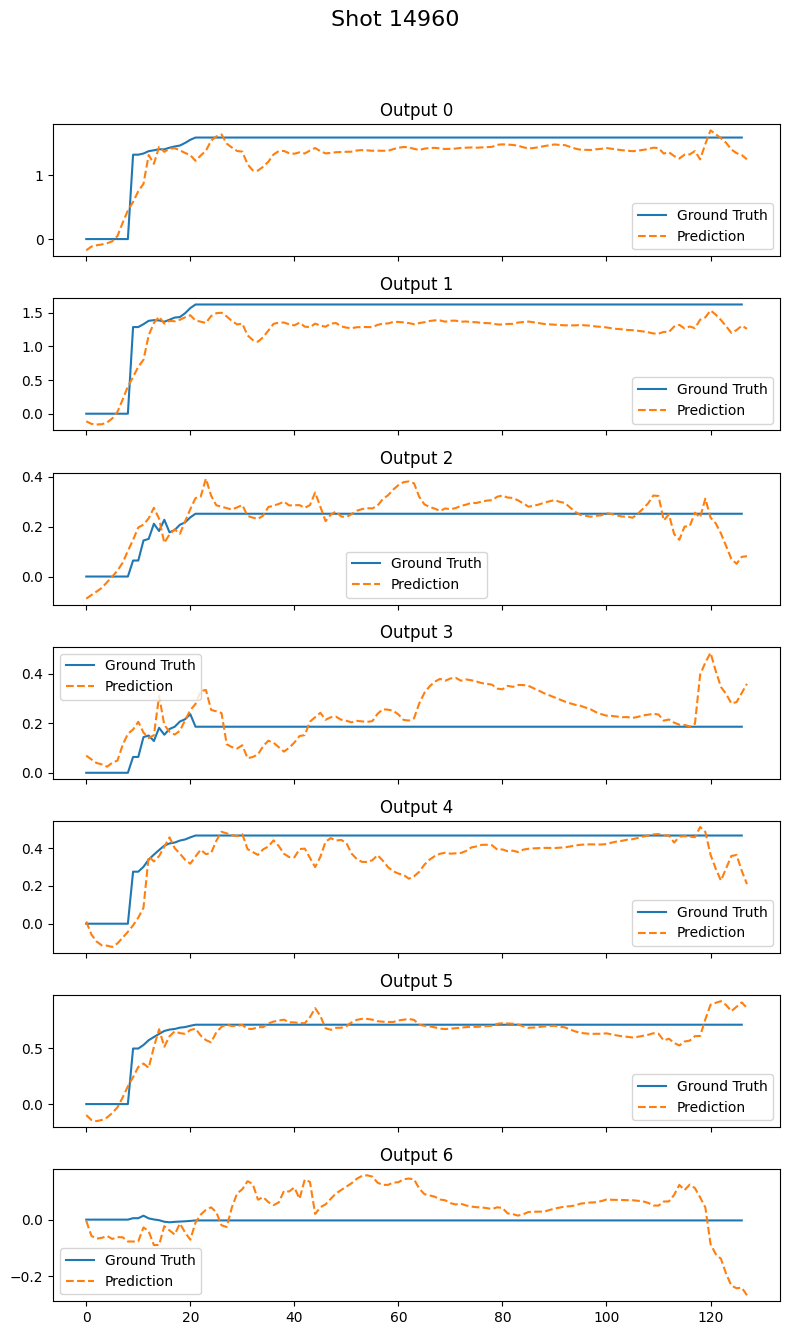

In [279]:
import matplotlib.pyplot as plt
import numpy as np

num_outputs = processed_y_test.shape[-1]

fig, axes = plt.subplots(num_outputs, 1, figsize=(8, 2 * num_outputs), sharex=True)
fig.suptitle(f'Shot 14960', fontsize=16)

if num_outputs == 1:
    axes = [axes]

for k in range(num_outputs):
    axes[k].plot(processed_y_test[:, k], label='Ground Truth')
    axes[k].plot(y_pred[:, k], label='Prediction', linestyle='--')
    axes[k].set_title(f'Output {k}')
    axes[k].legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # Adjust for suptitle
plt.show()
